# Price Optimisation

This notebook uses the pre-processed datasets and results from prior methodolohgy to optimise price setting in relation to emission minimisation and profit maximisation

## Importing the Data and Dependencies

Importing required packages:

In [1]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.optimize import linprog
import matplotlib.pyplot as plt
import cvxpy as cp

Mounting to Google Drive:

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


Importing the pre-processed data:

In [3]:
os.chdir('/content/drive/MyDrive/ERP/Processed_Data')

mef_sample = pd.read_csv("mef_sample.csv")

IS = np.array(pd.read_csv("IS.csv").iloc[:, 1:])
SC = np.array(pd.read_csv("SC.csv").iloc[:, 1:])
HS = np.array(pd.read_csv("HS.csv").iloc[:, 1:])

elasticities = [IS, SC, HS]

baseline_demand_curve = pd.read_csv("baseline_profile.csv")
wholesale_prices = pd.read_csv("wholesale_prices.csv")

## Optimisation Preparation

Setting the parameters for price optimisation:

In [4]:
avg_price = np.full(24, 15)
max_price = np.full(24, 25)
min_price = np.array(wholesale_prices.iloc[:,1:]).flatten()
baseline_demand = np.asarray(baseline_demand_curve.iloc[:,1:]).flatten()
mef_sample = np.array(mef_sample.iloc[:,1:])  # (100,24)


A function to calculate key metrics:

In [5]:
def get_results(new_demand, optimal_prices):
    profit = ((optimal_prices - min_price) * new_demand).sum()
    cost = (optimal_prices * new_demand).sum()
    wholesale_cost = (min_price * new_demand).sum()
    revenue = (optimal_prices * new_demand).sum()

    return {
        "profit": profit,
        "cost": cost,
        "wholesale_cost": wholesale_cost,
        "revenue": revenue
    }

## The Baseline

Calculating baselines results:

In [6]:
results_baseline = get_results(baseline_demand, avg_price)
results_baseline['emissions_change'] = float(0)
all_metrics_baseline = [results_baseline] * 3

## Emission Minimisation

Solving a linear minimisation problem to produce optimal price changes. The optimisation is simulated for each consumer group across 100 days of different MEF profiles:

In [7]:
all_demands_emissions  = [[] for _ in elasticities]
all_prices_emissions   = [[] for _ in elasticities]
n_mef = len(mef_sample)
all_metrics_emissions = [[] for _ in range(n_mef)]

avg_price_np = np.asarray(avg_price, dtype=float)
min_price_np = np.asarray(min_price, dtype=float)
max_price_np = np.asarray(max_price, dtype=float)
baseline_np  = np.asarray(baseline_demand, dtype=float)

min_change = min_price_np - avg_price_np
max_change = max_price_np - avg_price_np
n = avg_price_np.size

A_rows = [np.ones(n)]
b_vals = [0.0]

bounds = list(zip(min_change, max_change))

for e_idx, E_raw in enumerate(elasticities):
    E = np.asarray(E_raw, dtype=float)

    A_demand = -E
    b_demand = baseline_np

    A_ub = np.vstack([A_rows[0], A_demand])
    b_ub = np.concatenate([np.asarray(b_vals, float), b_demand])

    for m_idx, mef_raw in enumerate(mef_sample):
        mef_vec = np.asarray(mef_raw, dtype=float).reshape(-1, 1)
        scaled_em = E * mef_vec
        c = scaled_em.sum(axis=0)

        res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
        if not res.success:
            raise RuntimeError(f"[E#{e_idx} MEF#{m_idx}] linprog failed: {res.message}")

        delta_opt      = res.x
        optimal_price  = delta_opt + avg_price_np
        demand         = E @ delta_opt + baseline_np

        mef_flat = mef_vec.ravel()
        emissions_change   = float(((demand - baseline_np) * mef_flat).sum())
        emissions_change_2 = float((scaled_em @ delta_opt).sum())

        all_prices_emissions[e_idx].append(optimal_price)
        all_demands_emissions[e_idx].append(demand)

        metrics = get_results(demand, optimal_price)
        metrics["emissions_change"]   = emissions_change
        metrics["emissions_change_2"] = emissions_change_2
        metrics["elasticity_index"]   = e_idx
        metrics["mef_index"]          = m_idx
        all_metrics_emissions[m_idx].append(metrics)

prices_per_E  = [np.vstack(p_list) for p_list in all_prices_emissions]
demands_per_E = [np.vstack(d_list) for d_list in all_demands_emissions]

all_emissions_prices  = np.stack(prices_per_E, axis=0)
all_emissions_demands = np.stack(demands_per_E, axis=0)


## Joint Optimisation

Solving a joint optimisation model to prodcue price changes when the objective is weighted between profit maximisation and emission minimisation. Again this is simulated for each consumer group over the 100 sampled MEF observations.


In [8]:
avg_price_np = np.asarray(avg_price, dtype=float)
min_price_np = np.asarray(min_price, dtype=float)
max_price_np = np.asarray(max_price, dtype=float)
baseline_np  = np.asarray(baseline_demand, dtype=float)
mef_matrix   = np.asarray(mef_sample, dtype=float)
assert mef_matrix.ndim == 2, "mef_sample must be a 2D array-like of MEF vectors."

n_mef = mef_matrix.shape[0]
n = avg_price_np.size
min_change = min_price_np - avg_price_np
max_change = max_price_np - avg_price_np
ones_row = np.ones((1, n))

baseline_profit = ((avg_price_np - min_price_np) * baseline_np).sum()

elasticities_np = [np.asarray(E, dtype=float) for E in elasticities]


def build_solver_for_E(E, lam, ridge=1e-9, scipy_ftol=1e-6, scipy_maxiter=300):

    try:
        import cvxpy as cp
        Esym = 0.5 * (E + E.T)
        H = -2.0 * lam * Esym
        H = 0.5 * (H + H.T) + ridge * np.eye(n)
        q = cp.Parameter(n)

        delta = cp.Variable(n)
        constraints = [
            ones_row @ delta <= 0.0,
            -E @ delta <= baseline_np,
            delta >= min_change,
            delta <= max_change,
        ]
        obj = 0.5 * cp.quad_form(delta, H) + q @ delta
        prob = cp.Problem(cp.Minimize(obj), constraints)

        def solve_with_c(lin_vec, c_vec):
            q.value = -lam * lin_vec + (1.0 - lam) * c_vec
            prob.solve(solver=cp.OSQP, eps_abs=1e-6, eps_rel=1e-6,
                       max_iter=200000, polish=True)
            if prob.status not in ("optimal", "optimal_inaccurate"):
                raise RuntimeError(f"CVXPY status: {prob.status}")
            return np.asarray(delta.value, dtype=float)
        return solve_with_c

    except Exception:
        from scipy.optimize import minimize
        Esym = 0.5 * (E + E.T)

        def solve_with_c(lin_vec, c_vec):
            def obj(delta):
                profit    = lin_vec @ delta + delta @ (E @ delta)
                emissions = c_vec @ delta
                return -lam * profit + (1.0 - lam) * emissions

            def jac(delta):
                grad_profit = lin_vec + (Esym + Esym) @ delta
                return -lam * grad_profit + (1.0 - lam) * c_vec

            bounds = list(zip(min_change, max_change))
            cons = [{'type': 'ineq', 'fun': lambda d: -np.sum(d),
                     'jac':  lambda d: -np.ones_like(d)}]
            for k in range(n):
                Ek = E[k, :].copy()
                b  = baseline_np[k]
                cons.append({'type': 'ineq',
                             'fun': lambda d, Ek=Ek, b=b: b + Ek @ d,
                             'jac': lambda d, Ek=Ek: Ek})

            x0 = np.clip(np.zeros(n), min_change, max_change)
            m = x0.mean()
            if m > 0:
                x0 = np.clip(x0 - m, min_change, max_change)

            res = minimize(obj, x0, method='SLSQP', jac=jac,
                           bounds=bounds, constraints=cons,
                           options={'ftol': scipy_ftol, 'maxiter': scipy_maxiter, 'disp': False})
            if not res.success:
                raise RuntimeError("SciPy fallback failed to converge.")
            return res.x

        return solve_with_c

def sweep_joint_tradeoff_true_mean_over_mefs(lambdas):
    mean_dprofits   = np.zeros_like(lambdas, dtype=float)
    mean_demissions = np.zeros_like(lambdas, dtype=float)

    pre = []
    for E in elasticities_np:
        lin = baseline_np + E.T @ (avg_price_np - min_price_np)
        C_all = E.T @ mef_matrix.T
        pre.append((E, lin, C_all))

    for i, lam in enumerate(lambdas):
        solvers = [build_solver_for_E(E, lam) for (E, _, _) in pre]

        sum_dp_mef = 0.0
        sum_de_mef = 0.0

        for m in range(n_mef):
            tot_dp = 0.0
            tot_de = 0.0
            for solver, (E, lin, C_all) in zip(solvers, pre):
                c = C_all[:, m]
                delta_opt = solver(lin, c)

                optimal_price = delta_opt + avg_price_np
                demand        = E @ delta_opt + baseline_np

                d_emissions = float((demand - baseline_np) @ mef_matrix[m])
                profit_opt  = float(((optimal_price - min_price_np) * demand).sum())
                d_profit    = profit_opt - baseline_profit

                tot_dp += d_profit
                tot_de += d_emissions

            sum_dp_mef += tot_dp
            sum_de_mef += tot_de

        mean_dprofits[i]   = sum_dp_mef / n_mef
        mean_demissions[i] = sum_de_mef / n_mef

    return mean_dprofits, mean_demissions

lambdas = np.linspace(0.0, 1.0, 21)
profits_mean, emissions_mean = sweep_joint_tradeoff_true_mean_over_mefs(lambdas)

Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optima

Plotting he results for each lambda weighting to illustrate the trade-off between both objectives:

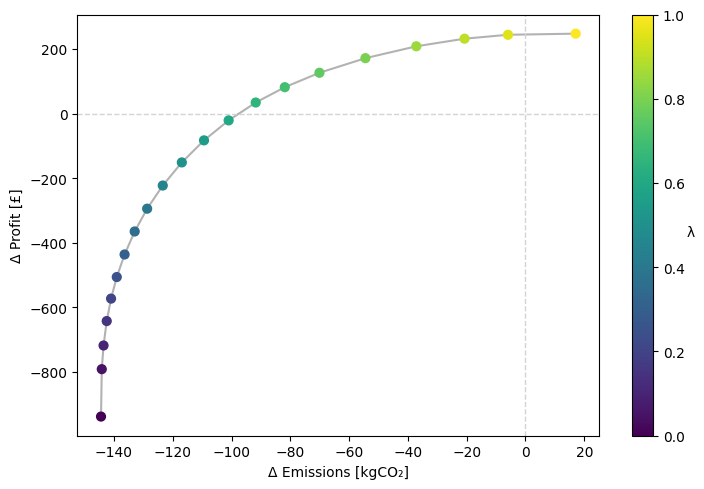

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))

profits_scaled = profits_mean * 10

sc = ax.scatter(emissions_mean, profits_scaled, c=lambdas, cmap='viridis', s=40, zorder=3)
ax.plot(emissions_mean, profits_scaled, '-', color='gray', alpha=0.6, zorder=2)

ax.set_xlabel("Δ Emissions [kgCO₂]")
ax.set_ylabel("Δ Profit [£]")

ax.axhline(0, color='lightgray', lw=1, ls='--')
ax.axvline(0, color='lightgray', lw=1, ls='--')


cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("λ", rotation=0)

fig.tight_layout()
plt.show()


Finding the lambda value at which profits are maintained to the baseline level and finding the range in which both objectives can be improved.

In [10]:
def zero_cross_lambda(xs, ys):
    out = []
    for i in range(len(xs)-1):
        y0, y1 = ys[i], ys[i+1]
        if (y0 == 0) or (y1 == 0):
            if y0 == 0: out.append(xs[i])
            if y1 == 0: out.append(xs[i+1])
        elif (y0 > 0) != (y1 > 0):
            t = -y0 / (y1 - y0)
            out.append(xs[i] + t*(xs[i+1]-xs[i]))
    return np.array(out, float)

lam_profit0 = zero_cross_lambda(lambdas, profits_mean).min()
emissions_at_profit0 = float(np.interp(lam_profit0, lambdas, emissions_mean))

lam_emiss0 = zero_cross_lambda(lambdas, emissions_mean).min()
profit_at_emiss0 = float(np.interp(lam_emiss0, lambdas, profits_mean))

print(f"Max mean emissions reduction with ΔProfit ≥ 0 ≈ {emissions_at_profit0:.6g}")
print(f"Max mean profit increase with ΔEmissions ≥ 0 ≈ {profit_at_emiss0:.6g}")
print(f"(λ at profit=0: {lam_profit0:.4f}; λ at emissions=0: {lam_emiss0:.4f})")

Max mean emissions reduction with ΔProfit ≥ 0 ≈ -97.4661
Max mean profit increase with ΔEmissions ≥ 0 ≈ 24.4875
(λ at profit=0: 0.6191; λ at emissions=0: 0.9629)


Running the joint optimisation for a zero change in profits to assess the economic feasibility of the CO2 reduction model:

In [11]:
avg_price_np = np.asarray(avg_price, dtype=float)
min_price_np = np.asarray(min_price, dtype=float)
max_price_np = np.asarray(max_price, dtype=float)
baseline_np  = np.asarray(baseline_demand, dtype=float)
min_change = min_price_np - avg_price_np
max_change = max_price_np - avg_price_np
n = avg_price_np.size
ones = np.ones((1, n))

lambda_val = lam_profit0

elasticities_np = [np.asarray(E_raw, float) for E_raw in elasticities]
mef_matrix = np.asarray(mef_sample, float)

all_prices_joint  = [[] for _ in range(len(mef_matrix))]
all_demands_joint = [[] for _ in range(len(mef_matrix))]
all_metrics_joint = [[] for _ in range(len(mef_matrix))]

for e_idx, E in enumerate(elasticities_np):
    Esym = 0.5*(E + E.T)
    H = -2.0*lambda_val*Esym

    lin = baseline_np + E.T.dot(avg_price_np - min_price_np)
    f0  = -lambda_val*lin

    A = np.vstack([ones, -E])
    b = np.hstack([0.0, baseline_np])

    delta = cp.Variable(n)
    H_psd = (H + H.T)/2
    q = cp.Parameter(n)

    constraints = [
        A @ delta <= b,
        delta >= min_change,
        delta <= max_change
    ]
    obj = 0.5*cp.quad_form(delta, H_psd) + q @ delta
    prob = cp.Problem(cp.Minimize(obj), constraints)

    solver_kwargs = dict(solver=cp.OSQP, eps_abs=1e-6, eps_rel=1e-6, max_iter=200000)

    for m_idx, mef in enumerate(mef_matrix):
        c = E.T @ mef
        q.value = f0 + (1.0 - lambda_val) * c
        prob.solve(**solver_kwargs)

        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"QP failed at (e={e_idx}, m={m_idx}): {prob.status}")

        delta_opt = delta.value
        optimal_price = delta_opt + avg_price_np
        demand = E @ delta_opt + baseline_np

        emissions_change = float((demand - baseline_np) @ mef)
        dprofit_opt = float(lin @ delta_opt + delta_opt @ (E @ delta_opt))
        demissions_opt = float(c @ delta_opt)

        all_prices_joint[m_idx].append(optimal_price)
        all_demands_joint[m_idx].append(demand)

        metrics = get_results(demand, optimal_price)
        metrics["emissions_change"]     = emissions_change
        metrics["emissions_change_2"]   = float((mef @ E) @ delta_opt)
        metrics["joint_profit_term"]    = dprofit_opt
        metrics["joint_emissions_term"] = demissions_opt
        metrics["lambda"]               = float(lambda_val)
        metrics["elasticity_index"]     = e_idx
        metrics["mef_index"]            = m_idx
        all_metrics_joint[m_idx].append(metrics)

prices_joint_by_day  = [np.vstack(p_list) for p_list in all_prices_joint]
demands_joint_by_day = [np.vstack(d_list) for d_list in all_demands_joint]
all_joint_prices  = np.stack(prices_joint_by_day, axis=0)
all_joint_demands = np.stack(demands_joint_by_day, axis=0)


## Functions to Compare Results

Creating a pipeline to generate results:

In [12]:
def print_baseline_results(all_metrics):
  df = {}
  df['revenue'] = sum(m["revenue"] for m in all_metrics) / 100 *1000
  df['profit'] = sum(m["profit"] for m in all_metrics) / 100 *1000
  df['wholesale_cost'] = sum(m["wholesale_cost"] for m in all_metrics) / 100 *1000
  df['emissions_change'] = sum(m["emissions_change"]  for m in all_metrics) *1000
  df['IS'] = all_metrics[0]['cost'] / 100 *1000
  df['SC'] = all_metrics[1]['cost'] / 100 *1000
  df['HS'] =all_metrics[2]['cost'] / 100 *1000
  df['total_consumer_cost'] = sum(m["cost"] for m in all_metrics) / 100 *1000
  return df

In [13]:
def print_mean_results(all_metrics_by_day, households_per_group=1000, cost_labels=None):

    key_map = {
        "profit":           "profit",
        "wholesale_cost":   "wholesale_cost",
        "revenue":          "revenue",
        "emissions_change": "emissions_change",
        "cost":             "total_consumer_cost",
    }

    max_groups = max(len(day_list) for day_list in all_metrics_by_day)

    default_labels = ["IS", "SC", "HS"]
    if cost_labels is None:
        cost_labels = (default_labels[:max_groups] if max_groups <= len(default_labels)
                       else default_labels + [f"consumer_cost_e{i}" for i in range(3, max_groups)])
    else:
        if len(cost_labels) > max_groups:
            cost_labels = cost_labels[:max_groups]
        elif len(cost_labels) < max_groups:
            cost_labels = cost_labels + [f"consumer_cost_e{i}" for i in range(len(cost_labels), max_groups)]

    group_cost_sums   = [0.0] * max_groups
    group_cost_counts = [0]   * max_groups

    daily_totals = []
    for day_list in all_metrics_by_day:
        day_sum = {out: 0.0 for out in key_map.values()}
        for idx, m in enumerate(day_list):
            if not isinstance(m, dict):
                continue

            for src_key, out_name in key_map.items():
                if src_key in m:
                    day_sum[out_name] += float(m[src_key]) * households_per_group

            if idx < max_groups and "cost" in m:
                group_cost_sums[idx]   += float(m["cost"]) * households_per_group
                group_cost_counts[idx] += 1

        daily_totals.append(day_sum)

    if not daily_totals:
        raise ValueError("No daily totals computed.")

    n_days = len(daily_totals)
    out = {k: sum(d[k] for d in daily_totals) / n_days for k in daily_totals[0].keys()}

    for i, label in enumerate(cost_labels):
        out[label] = (group_cost_sums[i] / group_cost_counts[i]) if group_cost_counts[i] > 0 else float("nan")

    monetary_keys = {"profit", "wholesale_cost", "revenue", "total_consumer_cost", *cost_labels}
    for k in list(out.keys()):
        v = out[k]
        if v is None or isinstance(v, str):
            continue
        if k in monetary_keys:
            out[k] = v / 100.0
        elif k == "emissions_change":
            out[k] = v / 1000.0

    return out


Creating to function to plot price and demand curves:

In [14]:
def plot_prices_and_demands(min_price, max_price,
                            baseline_demand,
                            IS_price, SC_price, HS_price,
                            IS_demand, SC_demand, HS_demand):
    n = len(min_price)
    x = np.arange(1, n + 1)

    base_styles = {
        "IS": dict(color="red",  linestyle="--", marker="X"),
        "SC": dict(color="blue", linestyle="-",  marker="*"),
        "HS": dict(color="lime", linestyle="--", marker="o"),
    }
    style_map = {k.lower(): v for k, v in base_styles.items()}

    mark_idx = list(range(2, n + 1, 2))
    mark_pos = [i for i in range(1, n) if (i + 1) in mark_idx]

    fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2, ncols=1, figsize=(10, 12),
        sharex=True, gridspec_kw=dict(hspace=0.25)
    )

    ax_top.step(x, max_price, where="post", color="black", label="Max price")
    ax_top.step(x, min_price, where="post", color="black",
                linestyle=(0, (6, 8)), label="Min price")

    for label, series in dict(IS=IS_price, SC=SC_price, HS=HS_price).items():
        st = style_map[label.lower()]
        ax_top.step(x, np.asarray(series).ravel(),
                    where="post", label=label, markevery=mark_pos, **st)

    ax_top.set_ylabel("Price (cents/kWh)", fontsize=11)
    ax_top.set_ylim(bottom=0)
    ax_top.tick_params(axis="x", labelbottom=False, top=True, labeltop=True)
    ax_top.legend(loc="best")

    ax_bot.plot(x, np.asarray(baseline_demand).ravel(),
                color="black", linewidth=1.8, label="Baseline")

    for label, series in dict(IS=IS_demand, SC=SC_demand, HS=HS_demand).items():
        st = style_map[label.lower()]
        ax_bot.plot(x, np.asarray(series).ravel(), label=label,
                    color=st["color"], linestyle=st["linestyle"])

    ax_bot.set_xlabel("Hour index of the day", fontsize=11)
    ax_bot.set_ylabel("Demand", fontsize=11)
    ax_bot.grid(False)
    ax_bot.tick_params(axis="x", top=True, labeltop=True)
    ax_bot.legend(loc="best")

    plt.tight_layout()
    plt.show()


In [15]:
def plot_prices_and_demands(min_price, max_price,
                            baseline_demand,
                            IS_price, SC_price, HS_price,
                            IS_demand, SC_demand, HS_demand):
    n = len(min_price)
    x = np.arange(1, n + 1)

    base_styles = {
        "IS": dict(color="red",  linestyle="--", marker="X"),
        "SC": dict(color="blue", linestyle="-",  marker="*"),
        "HS": dict(color="lime", linestyle="--", marker="o"),
    }
    style_map = {k.lower(): v for k, v in base_styles.items()}

    mark_idx = list(range(2, n + 1, 2))
    mark_pos = [i for i in range(1, n) if (i + 1) in mark_idx]

    fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2, ncols=1, figsize=(10, 11),
        sharex=True, gridspec_kw=dict(hspace=0.08)
    )

    ax_top.step(x, max_price, where="post", color="black", label="Max price")
    ax_top.step(x, min_price, where="post", color="black",
                linestyle=(0, (6, 8)), label="Min price")

    for label, series in dict(IS=IS_price, SC=SC_price, HS=HS_price).items():
        st = style_map[label.lower()]
        ax_top.step(x, np.asarray(series).ravel(),
                    where="post", label=label, markevery=mark_pos, **st)

    ax_top.set_ylabel("Electricity Price [£/kWh]", fontsize=11)
    ax_top.set_ylim(bottom=0)
    ax_top.tick_params(axis="x", labelbottom=False, top=True, labeltop=False)
    ax_top.legend(loc="best")

    ax_bot.plot(x, np.asarray(baseline_demand).ravel(),
                color="black", linewidth=1.8, label="Baseline")

    for label, series in dict(IS=IS_demand, SC=SC_demand, HS=HS_demand).items():
        st = style_map[label.lower()]
        ax_bot.plot(x, np.asarray(series).ravel(), label=label,
                    color=st["color"], linestyle=st["linestyle"])

    ax_bot.set_xlabel("Time of Day [Hour]", fontsize=11)
    ax_bot.set_ylabel("Average Electricity Consumption [kWh]", fontsize=11)
    ax_bot.grid(False)
    ax_bot.tick_params(axis="x", top=True, labeltop=False)
    ax_bot.legend(loc="best")

    ax_bot.set_xlim(1, n)

    plt.tight_layout()
    plt.show()



## Results Comparison



Printing mean results across the 100 simulations:

In [16]:
baseline_results = print_baseline_results(all_metrics_baseline)
emissions_mean_results = print_mean_results(all_metrics_emissions)
joint_mean_results = print_mean_results(all_metrics_joint)

all_results = {
    "Baseline": baseline_results,
    "Emission minimisation": emissions_mean_results,
    "Joint optimisation": joint_mean_results
}

results = pd.DataFrame.from_dict(all_results, orient="index")
results = results.round(0)
results

,revenue,profit,wholesale_cost,emissions_change,IS,SC,HS,total_consumer_cost
Baseline,4340.0,1908.0,2432.0,0.0,1447.0,1447.0,1447.0,4340.0
Emission minimisation,3386.0,966.0,2420.0,-144.0,1424.0,1139.0,823.0,3386.0
Joint optimisation,4320.0,1909.0,2412.0,-98.0,1609.0,1422.0,1290.0,4320.0


Plotting price and demand curves for different consumer groups from a random day:

Emission minimisation

/tmp/ipython-input-1527787941.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


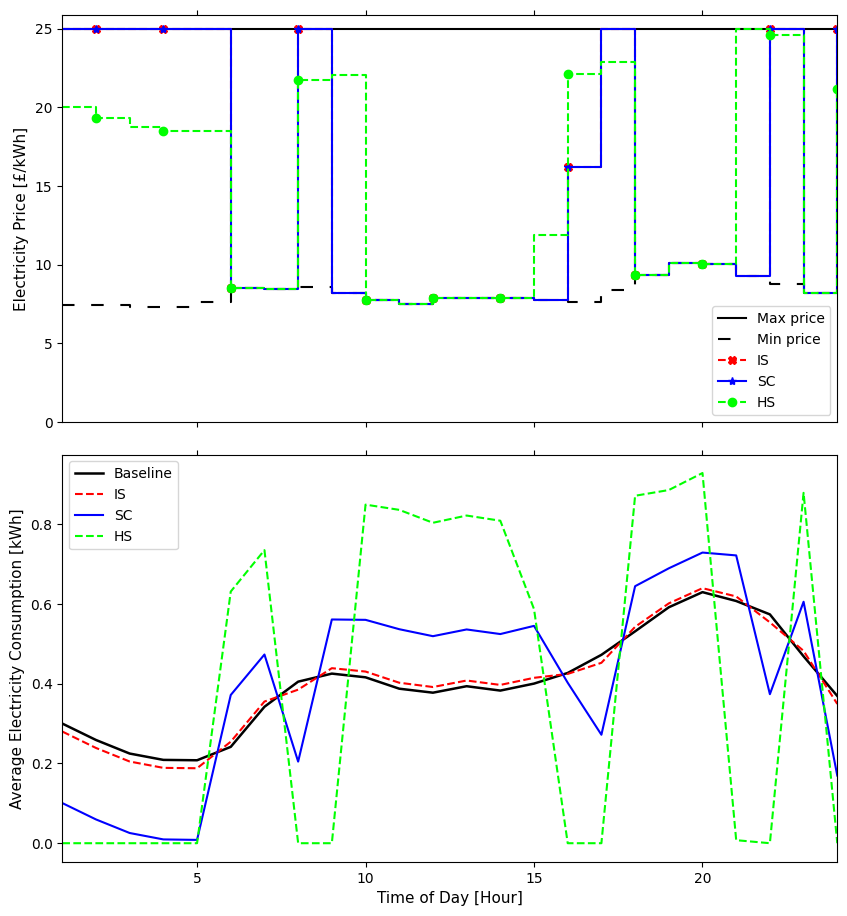

In [17]:
plot_prices_and_demands(
    min_price=min_price,
    max_price=max_price,
    baseline_demand=baseline_demand,
    IS_price=all_emissions_prices[0][n],
    SC_price=all_emissions_prices[1][n],
    HS_price=all_emissions_prices[2][n],
    IS_demand=all_demands_emissions[0][n],
    SC_demand=all_demands_emissions[1][n],
    HS_demand=all_demands_emissions[2][n],
)

Joint optimisation

/tmp/ipython-input-1527787941.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


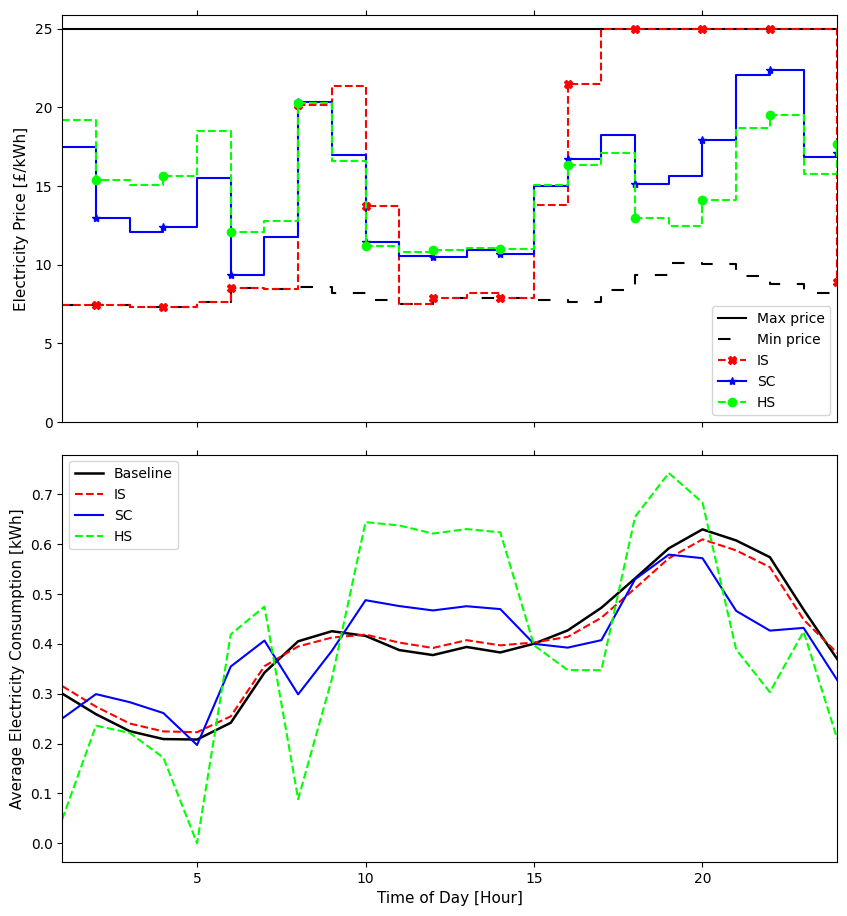

In [18]:
plot_prices_and_demands(
    min_price=min_price,
    max_price=max_price,
    baseline_demand=baseline_demand,
    IS_price=all_prices_joint[n][0],
    SC_price=all_prices_joint[n][1],
    HS_price=all_prices_joint[n][2],
    IS_demand=all_demands_joint[n][0],
    SC_demand=all_demands_joint[n][1],
    HS_demand=all_demands_joint[n][2],
)

Plotting the distributions of emission chnages for both the emission minimisation model and joint optimisation model

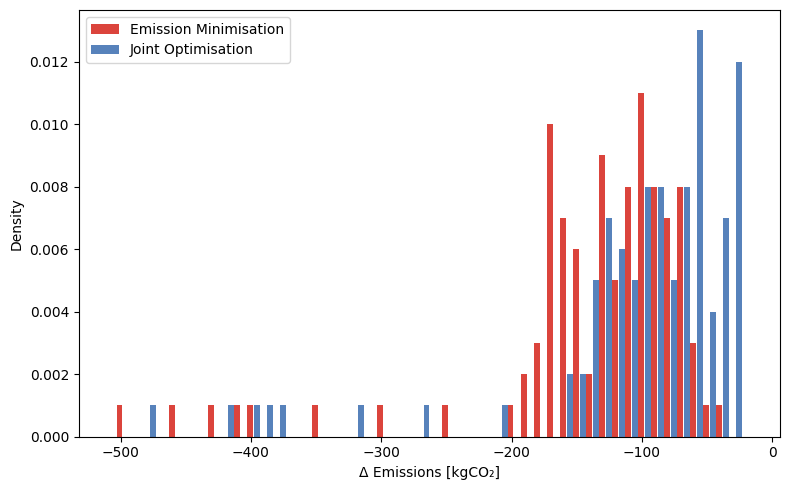

In [19]:
def sum_emissions(metrics_by_day):
    return np.array([
        sum(m["emissions_change"] for m in day_metrics)
        for day_metrics in metrics_by_day
    ])

emissions_joint     = sum_emissions(all_metrics_joint)
emissions_emissions = sum_emissions(all_metrics_emissions)

bins = np.linspace(
    min(emissions_joint.min(), emissions_emissions.min()),
    max(emissions_joint.max(), emissions_emissions.max()),
    50)

dens_joint, _ = np.histogram(emissions_joint, bins=bins, density=True)
dens_emis,  _ = np.histogram(emissions_emissions, bins=bins, density=True)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
width = (bins[1] - bins[0]) * 0.45

plt.figure(figsize=(8,5))
plt.bar(bin_centers + width/2, dens_emis, width=width,
        label="Emission Minimisation", color="#d73027", alpha=0.9)
plt.bar(bin_centers - width/2, dens_joint, width=width,
        label="Joint Optimisation", color="#4575b4", alpha=0.9)


plt.xlabel("Δ Emissions [kgCO₂]")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


Min change and top 5% quantile for emission minimisation:

In [20]:
print(np.quantile(emissions_emissions, 0.05))
print(np.max(emissions_emissions))

-352.7063745911151
-44.371381289446404


Min change and top 5% quantile for joint optimisation

In [21]:
print(np.quantile(emissions_joint, 0.05))
print(np.max(emissions_joint))

-318.1309824951237
-18.029269337846987
